# Step 21 — heatmap: the same patients, grouped alone and grouped federated

**Data type: RNA_array** (GSE65391). **Reads:** `step18_site_*` (alone models), `step13_site_*`
(federated labels), `step13_model.rds`. **Writes:** `figures/fig21_RNA_array_alone_vs_federated_{A,B,C}.png`.

For each site, its SLE patients at their first visit, drawn twice with the same rows and colours:

- **left**, grouped by the site's own endotypes (step 18);
- **right**, grouped by the federated endotypes (step 13).

Rows are the federated marker genes (30 per endotype) and the six interferon-score genes, scaled with
the pooled discovery mean and SD, as in step 15. Where the site's own groups are real, the colour
blocks line up with them. Where they are noise, the same blocks cut across them.

In [1]:
source("../src/paths.R")
source("../src/endotypes.R")
source("../src/federation.R")
source("../src/figures.R")
start_log("21")
model <- readRDS(art("step13_model.rds")); ce <- model$centroids
markers <- unlist(lapply(rownames(ce), function(e) {
  d <- ce[e, ] - colMeans(ce[rownames(ce) != e, , drop = FALSE]); names(sort(d, decreasing = TRUE))[1:30] }))
ifn6 <- read_gene_set("ifn-type1-6.txt")
rows <- unique(c(markers, ifn6))
row_block <- factor(ifelse(rows %in% ifn6, "interferon", paste("marks", rep(rownames(ce), each = 30)[match(rows, markers)])),
                    levels = c(paste("marks", rownames(ce)), "interferon"))
ps <- pool_suff(lapply(SITES, function(s) {
  d <- readRDS(site_file("13", s)); j <- d$meta$split == "discovery"
  send(site_suff(d$E[rows, j]), s, "row-gene sums, discovery", sum(j))
}))
row_mean <- ps$mean; row_sd <- sqrt(ps$var)
ALONE_COL <- setNames(hcl.colors(6, "Dark 3"), paste0("E", 1:6))
FED_COL   <- endotype_colours(rownames(ce))

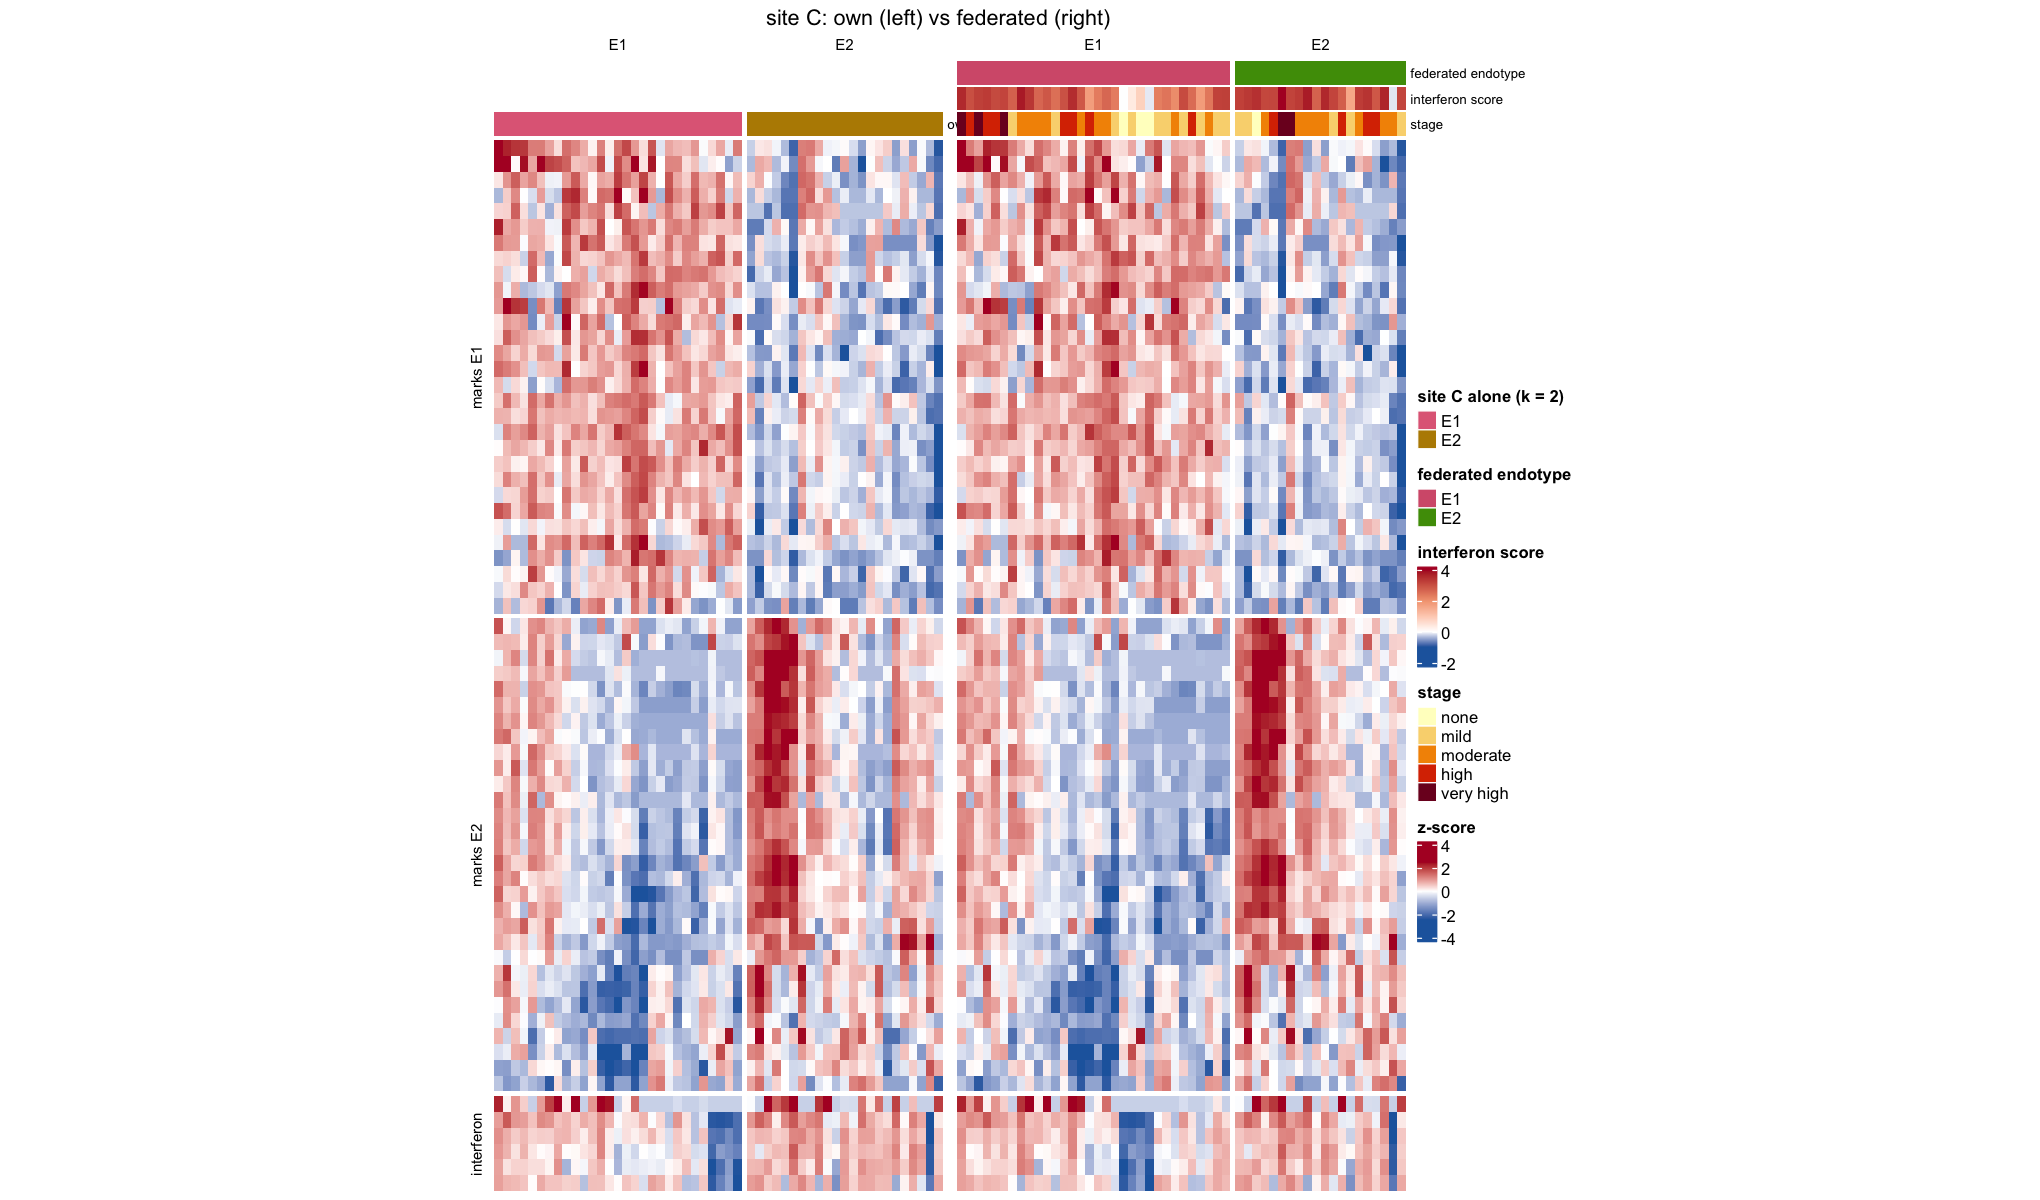

In [2]:
pair_heatmap <- function(s) {
  d <- readRDS(site_file("13", s)); m <- d$meta
  f <- m[m$disease == "SLE", ]; f <- f[order(f$subject, f$visit), ]; j <- rownames(f)[!duplicated(f$subject)]
  alone <- readRDS(site_file("18", s))
  a_lab <- as.character(nearest_centroid(t(d$E[alone$genes, j] - alone$centre), alone$centroids)$endotype)
  M <- (d$E[rows, j] - row_mean) / row_sd; M[M > 2.5] <- 2.5; M[M < -2.5] <- -2.5
  left <- Heatmap(M, name = "z_own", col = Z_COL, show_heatmap_legend = FALSE,
    column_split = factor(a_lab), row_split = row_block, cluster_row_slices = FALSE, cluster_column_slices = FALSE,
    clustering_method_columns = "ward.D2", clustering_method_rows = "ward.D2",
    show_column_dend = FALSE, show_row_dend = FALSE, show_column_names = FALSE, show_row_names = FALSE,
    row_title_gp = gpar(fontsize = 9), column_title_gp = gpar(fontsize = 9),
    top_annotation = HeatmapAnnotation("own group" = a_lab, col = list("own group" = ALONE_COL),
      annotation_name_gp = gpar(fontsize = 8),
      annotation_legend_param = list("own group" = list(title = sprintf("site %s alone (k = %d)", s, alone$k)))),
    width = unit(95, "mm"))
  right <- Heatmap(M, name = "z-score", col = Z_COL,
    column_split = factor(as.character(m[j, "endotype"])), cluster_column_slices = FALSE,
    clustering_method_columns = "ward.D2", show_column_dend = FALSE, show_column_names = FALSE,
    show_row_names = FALSE, column_title_gp = gpar(fontsize = 9),
    top_annotation = HeatmapAnnotation("federated endotype" = as.character(m[j, "endotype"]),
      "interferon score" = f[j, "ifn_score"], stage = f[j, "stage"],
      col = list("federated endotype" = FED_COL, "interferon score" = IFN_COL, stage = STAGE_COL),
      annotation_name_gp = gpar(fontsize = 8)),
    width = unit(95, "mm"))
  left + right
}
for (s in SITES) {
  png(fig("fig21_RNA_array_alone_vs_federated_%s.png", s), width = 2600, height = 1500, res = 170)
  draw(pair_heatmap(s), column_title = sprintf("site %s: its own endotypes (left) and the federated endotypes (right)", s),
       merge_legend = TRUE)
  invisible(dev.off())
}
options(repr.plot.width = 17, repr.plot.height = 10)
for (s in SITES) draw(pair_heatmap(s), column_title = sprintf("site %s: own (left) vs federated (right)", s), merge_legend = TRUE)

## Findings

At site C, alone and federated give nearly the same two blocks: lymphocyte genes high on one side,
granulocyte genes high on the other. At sites A and B, the site's own five or six groups cut across
those blocks. Several of the small groups hold one or two patients, and the same marker pattern runs
through more than one group. The federated grouping recovers the two blocks at every site.